In [1]:
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.competition_download('ieee-fraud-detection')
train = pd.read_csv(f'{path}/train_transaction.csv', index_col='TransactionID')
print(f'Shape: {train.shape}')
print(f'Fraud rate: {train["isFraud"].mean() * 100:.2f}%')

/Users/cjan/golark/frauddetection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (590540, 393)
Fraud rate: 3.50%


In [2]:
features = [
    'TransactionAmt', 'ProductCD',
    'card1', 'card2', 'card3', 'card5',
    'addr1', 'addr2', 'dist1',
    'P_emaildomain', 'R_emaildomain',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
]

X = train[features].copy()
y = train['isFraud'].copy()
print(f'X shape: {X.shape}')

X shape: (590540, 49)


In [3]:
cat_cols = X.select_dtypes(['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()
print(f'Categorical: {cat_cols}')

Categorical: ['ProductCD', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = X_train[col].fillna('MISSING').astype(str)
    X_test[col] = X_test[col].fillna('MISSING').astype(str)
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

for col in num_cols:
    train_med = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_med)
    X_test[col] = X_test[col].fillna(train_med)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Test fraud rate: {y_test.mean() * 100:.2f}%')

Train: (472432, 49), Test: (118108, 49)
Test fraud rate: 3.50%


In [5]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 8,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
}

t0 = time.time()
model = xgb.train(params, dtrain, num_boost_round=300, verbose_eval=50)
t_train = time.time() - t0

t0 = time.time()
y_proba = model.predict(dtest)
t_infer = time.time() - t0

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'\nTrain time: {t_train:.1f}s')
print(f'Inference time: {t_infer:.3f}s')
print(f'PR-AUC: {pr_auc:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')


Train time: 9.6s
Inference time: 0.167s
PR-AUC: 0.7582
ROC-AUC: 0.9608


In [6]:
from sklearn.metrics import classification_report

y_pred = (y_proba > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       0.99      0.95      0.97    113975
       Fraud       0.39      0.83      0.53      4133

    accuracy                           0.95    118108
   macro avg       0.69      0.89      0.75    118108
weighted avg       0.97      0.95      0.96    118108



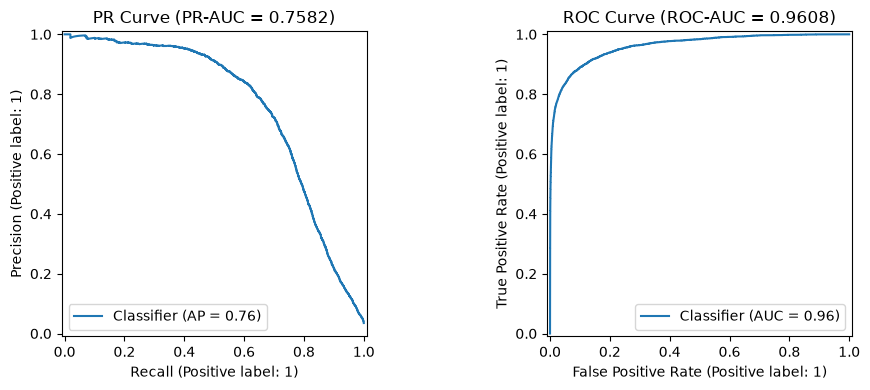

In [7]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax1)
ax1.set_title(f'PR Curve (PR-AUC = {pr_auc:.4f})')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2)
ax2.set_title(f'ROC Curve (ROC-AUC = {roc_auc:.4f})')

plt.tight_layout()
plt.show()

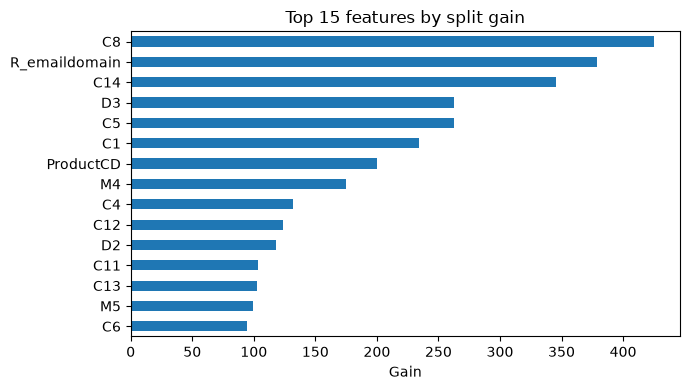

In [8]:
importances = pd.Series(model.get_score(importance_type='gain'), name='gain')
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 4))
top15.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Gain')
ax.set_title('Top 15 features by split gain')
plt.tight_layout()
plt.show()